## Experiment 2.1
In this part of second assignment we should implement several matrix factorization algoritms and comrate them to each other using evaluation framework.

Agenta:
1. FunkSVD
2. Alternating Least Squares (ALS)
3. Neural Collaborative Filtering (NCF)

### FunkSVD

In this part we will cover **FunkSVD** algorithm.


### Data Preparation
As usual we should load data and convert it to easy to use format, we will use an utility, that we implemented earlier to download latest dataset from an official resource page (Check and `README.md` for detailed instructions).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import ndcg_score
from tqdm.notebook import tqdm
from math import sqrt

In [2]:
data = pd.read_csv('../../data/ml-1m/ratings.dat', sep='::', header=None, names=['user_id', 'item_id', 'rating', 'timestamp'], engine='python', encoding='latin-1')

In [3]:
data.head()

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


We need to preprocess the data to create a user-item rating matrix and initialize the parameters for the FunkSVD algorithm. Then we will split data into train/test sets, to run benchmark into future.

In [4]:
def preprocess_data(data):
    user_item_matrix = data.pivot(index='user_id', columns='item_id', values='rating').fillna(0)
    R = user_item_matrix.values
    return R

R = preprocess_data(data)
num_users, num_items = R.shape

In [5]:
R

array([[5., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [3., 0., 0., ..., 0., 0., 0.]])

In [6]:
def train_test_split_matrix(R, test_size=0.2):
    train = R.copy()
    test = np.zeros(R.shape)
    for user in range(R.shape[0]):
        test_ratings = np.random.choice(R[user, :].nonzero()[0], 
                                        size=int(test_size * len(R[user, :].nonzero()[0])),
                                        replace=False)
        train[user, test_ratings] = 0.0
        test[user, test_ratings] = R[user, test_ratings]
    
    return train, test

train, test = train_test_split_matrix(R)

Now we should implement FunkSVD algorithm.

The goal of FunkSVD is to factorize the user-item rating matrix $( R )$ into two lower-dimensional matrices $( P )$ (user-feature matrix) and $( Q )$ (item-feature matrix) such that $( R \approx PQ^T )$.

**Algorithm Steps**
1. Initialize $( P )$ and $( Q )$ with small random values.
2. For each known rating $( r_{ij} )$ in $( R )$, update the user and item latent feature vectors:
   $$
   e_{ij} = r_{ij} - \mathbf{p}_i^T \mathbf{q}_j
   $$
   $$
   \mathbf{p}_i \leftarrow \mathbf{p}_i + \alpha (e_{ij} \mathbf{q}_j - \lambda \mathbf{p}_i)
   $$
   $$
   \mathbf{q}_j \leftarrow \mathbf{q}_j + \alpha (e_{ij} \mathbf{p}_i - \lambda \mathbf{q}_j)
   $$
   where $( \alpha )$ is the learning rate and $( \lambda )$ is the regularization parameter.
3. Repeat step 2 for a predefined number of epochs or until convergence. Implement early stopping if the error does not decrease significantly over epochs.

In [7]:
def mse(R, P, Q, mask):
    return np.sum((mask * (R - np.dot(P, Q.T)))**2) / np.sum(mask)

def funk_svd(R, num_features=15, learning_rate=0.001, regularization=0.01, 
             epochs=100, early_stopping=True, tolerance=0.001):
    num_users, num_items = R.shape
    np.random.seed(42)
    P = np.random.normal(scale=1./num_features, size=(num_users, num_features))
    Q = np.random.normal(scale=1./num_features, size=(num_items, num_features))
    mask = R > 0
    errors = []
    prev_error = np.inf
    
    for epoch in range(epochs):
        for i in range(num_users):
            for j in range(num_items):
                if R[i, j] > 0:
                    error_ij = R[i, j] - np.dot(P[i, :], Q[j, :].T)
                    P[i, :] += learning_rate * (error_ij * Q[j, :] - regularization * P[i, :])
                    Q[j, :] += learning_rate * (error_ij * P[i, :] - regularization * Q[j, :])
        
        error = mse(R, P, Q, mask)
        errors.append(error)
        print(f'Epoch {epoch + 1}/{epochs}, Error: {error}')
        
        if early_stopping and abs(prev_error - error) < tolerance:
            print("Early stopping...")
            break
        
        prev_error = error
    
    return P, Q, errors

P, Q, errors = funk_svd(train)

Epoch 1/100, Error: 14.069173061974418
Epoch 2/100, Error: 14.004751588278486
Epoch 3/100, Error: 12.933282557582652
Epoch 4/100, Error: 7.364346317726525
Epoch 5/100, Error: 3.6602928942427884
Epoch 6/100, Error: 2.353193128568053
Epoch 7/100, Error: 1.7689109499794669
Epoch 8/100, Error: 1.4613406926327808
Epoch 9/100, Error: 1.2796527050425048
Epoch 10/100, Error: 1.16339051219914
Epoch 11/100, Error: 1.0845490018039057
Epoch 12/100, Error: 1.0286659586561895
Epoch 13/100, Error: 0.9876364828882053
Epoch 14/100, Error: 0.9566226724193262
Epoch 15/100, Error: 0.9325885619798961
Epoch 16/100, Error: 0.9135497460194418
Epoch 17/100, Error: 0.898164326411522
Epoch 18/100, Error: 0.8854982306611949
Epoch 19/100, Error: 0.8748847243778046
Epoch 20/100, Error: 0.8658372573477597
Epoch 21/100, Error: 0.8579937470403834
Epoch 22/100, Error: 0.8510800505990395
Epoch 23/100, Error: 0.8448855119397112
Epoch 24/100, Error: 0.8392463126130099
Epoch 25/100, Error: 0.8340339803480263
Epoch 26/100, 

In [8]:
# Model Evaluation
def rmse(R, predicted_ratings, mask):
    return np.sqrt(np.sum((mask * (R - predicted_ratings))**2) / np.sum(mask))

In [9]:
predicted_ratings = np.dot(P, Q.T)

In [10]:
train_mask = train > 0
test_mask = test > 0

train_rmse = rmse(train, predicted_ratings, train_mask)
test_rmse = rmse(test, predicted_ratings, test_mask)

In [11]:
print(f'Train RMSE: {train_rmse}')
print(f'Test RMSE: {test_rmse}')

Train RMSE: 0.7904160882125871
Test RMSE: 0.8648223780256944


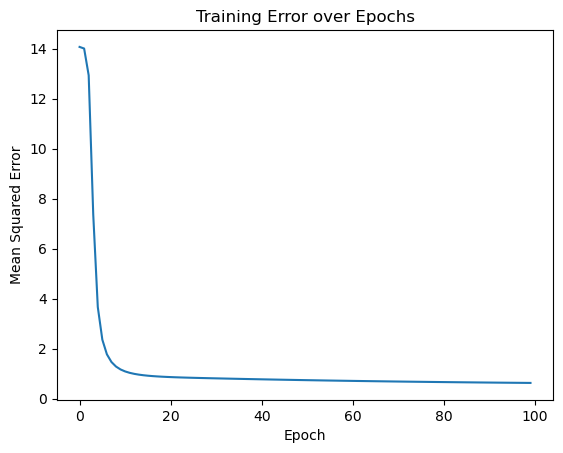

In [12]:
plt.plot(errors)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training Error over Epochs')
plt.show()

Decent results. We already implemented stop criteria as an improvements.
Now i wanna determine a best regularization parameter $\lambda$ using cross validation approach.

In [13]:
def cross_validate(R, num_features=15, learning_rate=0.007, regularization_values=[0.01, 0.02, 0.05], 
                   epochs=100, early_stopping=True, tolerance=0.001):
    best_reg = None
    best_rmse = np.inf
    best_P, best_Q = None, None
    all_errors = []
    
    for reg in regularization_values:
        print(f"Testing regularization: {reg}")
        P, Q, errors = funk_svd(R, num_features=num_features, learning_rate=learning_rate, 
                           regularization=reg, epochs=epochs, early_stopping=early_stopping, tolerance=tolerance)
        all_errors.append(errors)
        predicted_ratings = np.dot(P, Q.T)
        test_rmse = rmse(test, predicted_ratings, test_mask)
        print(f"Test RMSE for regularization {reg}: {test_rmse}")
        
        if test_rmse < best_rmse:
            best_rmse = test_rmse
            best_reg = reg
            best_P, best_Q = P, Q
    
    return best_P, best_Q, best_reg, best_rmse, all_errors

In [14]:
best_P, best_Q, best_reg, best_rmse, all_errors = cross_validate(train)
print(f"Best regularization: {best_reg}")
print(f"Best test RMSE: {best_rmse}")

Testing regularization: 0.01
Epoch 1/100, Error: 9.737146767358444
Epoch 2/100, Error: 2.632806498218924
Epoch 3/100, Error: 1.1733686393603486
Epoch 4/100, Error: 0.9697539507157094
Epoch 5/100, Error: 0.8816808373409865
Epoch 6/100, Error: 0.8293575998938801
Epoch 7/100, Error: 0.7910593068252453
Epoch 8/100, Error: 0.7598897711209396
Epoch 9/100, Error: 0.7336523539531729
Epoch 10/100, Error: 0.711345661455711
Epoch 11/100, Error: 0.6922507353438025
Epoch 12/100, Error: 0.675816401368228
Epoch 13/100, Error: 0.6616116715845264
Epoch 14/100, Error: 0.6492888451801939
Epoch 15/100, Error: 0.6385575788922936
Epoch 16/100, Error: 0.6291698803499116
Epoch 17/100, Error: 0.6209138572868458
Epoch 18/100, Error: 0.6136108858947726
Epoch 19/100, Error: 0.6071126043561669
Epoch 20/100, Error: 0.6012969756427892
Epoch 21/100, Error: 0.5960639745776318
Epoch 22/100, Error: 0.591331520327832
Epoch 23/100, Error: 0.5870319707442334
Epoch 24/100, Error: 0.5831092472126227
Epoch 25/100, Error: 0.57

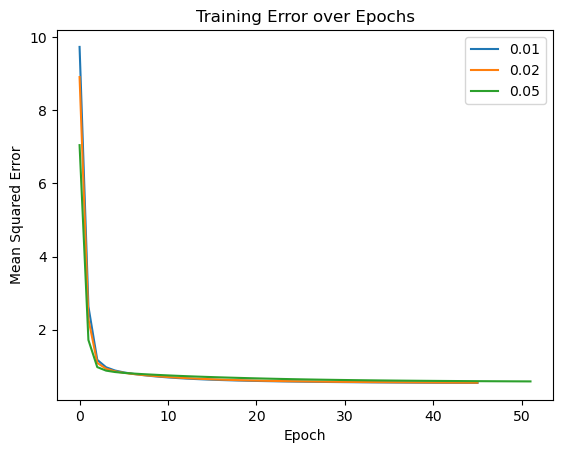

In [15]:
for index, errors in enumerate(all_errors):
    plt.plot(errors, label=list([0.01, 0.02, 0.05])[index])
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training Error over Epochs')
plt.legend()
plt.show()

As we can see, cross_validation shows that the best regularization parameter is `0.05`, but without significant difference between other values. The main problem I see is a static learning rate parameter, which work withot precision.

Let's try to address this issue and solve it using Adam optimizer approach and learning rate scheduling.

Here is an updated code for svd algorithm.

In [16]:
def funk_svd_adam(R, num_features=15, learning_rate=0.001, regularization=0.01, 
                  epochs=100, early_stopping=True, tolerance=0.001, 
                  beta1=0.9, beta2=0.999, epsilon=1e-8, lr_schedule=False, decay_factor=0.1, patience=10):
    num_users, num_items = R.shape
    np.random.seed(42)
    P = np.random.normal(scale=1./np.sqrt(num_features), size=(num_users, num_features))
    Q = np.random.normal(scale=1./np.sqrt(num_features), size=(num_items, num_features))
    mask = R > 0
    errors = []
    prev_error = np.inf
    
    # Adam optimizer variables
    m_P, v_P = np.zeros_like(P), np.zeros_like(P)
    m_Q, v_Q = np.zeros_like(Q), np.zeros_like(Q)
    t = 0
    
    no_improvement_count = 0  # For early stopping
    
    for epoch in range(epochs):
        t += 1
        for i in range(num_users):
            for j in range(num_items):
                if R[i, j] > 0:
                    error_ij = R[i, j] - np.dot(P[i, :], Q[j, :].T)
                    grad_P = error_ij * Q[j, :] - regularization * P[i, :]
                    grad_Q = error_ij * P[i, :] - regularization * Q[j, :]
                    
                    # Update biased first moment estimate
                    m_P[i, :] = beta1 * m_P[i, :] + (1 - beta1) * grad_P
                    m_Q[j, :] = beta1 * m_Q[j, :] + (1 - beta1) * grad_Q
                    
                    # Update biased second moment estimate
                    v_P[i, :] = beta2 * v_P[i, :] + (1 - beta2) * (grad_P**2)
                    v_Q[j, :] = beta2 * v_Q[j, :] + (1 - beta2) * (grad_Q**2)
                    
                    # Compute bias-corrected first moment estimate
                    m_hat_P = m_P[i, :] / (1 - beta1**t)
                    m_hat_Q = m_Q[j, :] / (1 - beta1**t)
                    
                    # Compute bias-corrected second moment estimate
                    v_hat_P = v_P[i, :] / (1 - beta2**t)
                    v_hat_Q = v_Q[j, :] / (1 - beta2**t)
                    
                    # Update parameters
                    P[i, :] += learning_rate * m_hat_P / (np.sqrt(v_hat_P) + epsilon)
                    Q[j, :] += learning_rate * m_hat_Q / (np.sqrt(v_hat_Q) + epsilon)
        
        error = mse(R, P, Q, mask)
        errors.append(error)
        print(f'Epoch {epoch + 1}/{epochs}, Error: {error}')
        
        # Early stopping
        if early_stopping and abs(prev_error - error) < tolerance:
            print("Early stopping...")
            break
        
        if lr_schedule and error >= prev_error:
            no_improvement_count += 1
            if no_improvement_count >= patience:
                learning_rate *= decay_factor
                print(f"Reducing learning rate to {learning_rate}")
                no_improvement_count = 0
        else:
            no_improvement_count = 0
        
        prev_error = error
    
    return P, Q, errors

In [17]:
P_b, Q_b, errors_b = funk_svd_adam(train, learning_rate=0.01, regularization=0.05, lr_schedule=True)

Epoch 1/100, Error: 4.521282989181213
Epoch 2/100, Error: 1.2990079968185384
Epoch 3/100, Error: 0.8336370198988432
Epoch 4/100, Error: 0.7918761445085408
Epoch 5/100, Error: 0.7721314980154839
Epoch 6/100, Error: 0.758908194592751
Epoch 7/100, Error: 0.7488174822163255
Epoch 8/100, Error: 0.7405054058163122
Epoch 9/100, Error: 0.7333045117534818
Epoch 10/100, Error: 0.7268532891863886
Epoch 11/100, Error: 0.7209453117339929
Epoch 12/100, Error: 0.7154565827717394
Epoch 13/100, Error: 0.710307617391941
Epoch 14/100, Error: 0.7054435980646262
Epoch 15/100, Error: 0.7008242655173369
Epoch 16/100, Error: 0.6964188005687874
Epoch 17/100, Error: 0.6922030895572195
Epoch 18/100, Error: 0.6881580986301838
Epoch 19/100, Error: 0.6842688044698698
Epoch 20/100, Error: 0.6805234448512741
Epoch 21/100, Error: 0.6769129580393255
Epoch 22/100, Error: 0.6734305105973828
Epoch 23/100, Error: 0.6700710374753823
Epoch 24/100, Error: 0.6668307567964754
Epoch 25/100, Error: 0.6637066672481456
Epoch 26/100

Train RMSE: 0.77181754826525
Test RMSE: 0.8596774157961629


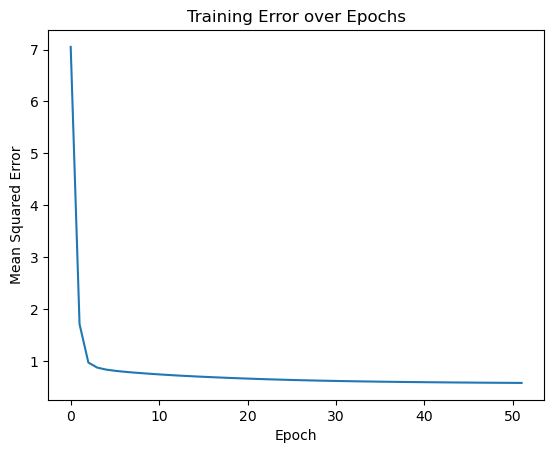

In [18]:
predicted_ratings = np.dot(P_b, Q_b.T)
train_mask = train > 0
test_mask = test > 0

train_rmse = rmse(train, predicted_ratings, train_mask)
test_rmse = rmse(test, predicted_ratings, test_mask)

print(f'Train RMSE: {train_rmse}')
print(f'Test RMSE: {test_rmse}')

plt.plot(errors)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training Error over Epochs')
plt.show()

We will stick with this realization, since it is most efficient one.

Here is an updated algorithm for this implementation usign Adam optimizer and learning rate scheduling.

1. **Initialization**: Initialize $( P )$ and $( Q )$ with small random values. Set the hyperparameters for Adam: $( \alpha )$ (learning rate), $( \beta_1 )$, $( \beta_2 )$, and $( \epsilon )$. Optionally, set parameters for learning rate scheduling: decay factor and patience.

2. **Iterative Updates**: For each known rating $( r_{ij} )$ in $( R )$, update the user and item latent feature vectors using the Adam optimizer:
   $$
   e_{ij} = r_{ij} - \mathbf{p}_i^T \mathbf{q}_j
   $$
   $$
   g_{\mathbf{p}_i} = e_{ij} \mathbf{q}_j - \lambda \mathbf{p}_i
   $$
   $$
   g_{\mathbf{q}_j} = e_{ij} \mathbf{p}_i - \lambda \mathbf{q}_j
   $$
   Update the biased first moment estimate:
   $$
   m_{\mathbf{p}_i} = \beta_1 m_{\mathbf{p}_i} + (1 - \beta_1) g_{\mathbf{p}_i}
   $$
   $$
   m_{\mathbf{q}_j} = \beta_1 m_{\mathbf{q}_j} + (1 - \beta_1) g_{\mathbf{q}_j}
   $$
   Update the biased second moment estimate:
   $$
   v_{\mathbf{p}_i} = \beta_2 v_{\mathbf{p}_i} + (1 - \beta_2) g_{\mathbf{p}_i}^2
   $$
   $$
   v_{\mathbf{q}_j} = \beta_2 v_{\mathbf{q}_j} + (1 - \beta_2) g_{\mathbf{q}_j}^2
   $$
   Compute the bias-corrected first moment estimate:
   $$
   \hat{m}_{\mathbf{p}_i} = \frac{m_{\mathbf{p}_i}}{1 - \beta_1^t}
   $$
   $$
   \hat{m}_{\mathbf{q}_j} = \frac{m_{\mathbf{q}_j}}{1 - \beta_1^t}
   $$
   Compute the bias-corrected second moment estimate:
   $$
   \hat{v}_{\mathbf{p}_i} = \frac{v_{\mathbf{p}_i}}{1 - \beta_2^t}
   $$
   $$
   \hat{v}_{\mathbf{q}_j} = \frac{v_{\mathbf{q}_j}}{1 - \beta_2^t}
   $$
   Update the parameters:
   $$
   \mathbf{p}_i \leftarrow \mathbf{p}_i + \alpha \frac{\hat{m}_{\mathbf{p}_i}}{\sqrt{\hat{v}_{\mathbf{p}_i}} + \epsilon}
   $$
   $$
   \mathbf{q}_j \leftarrow \mathbf{q}_j + \alpha \frac{\hat{m}_{\mathbf{q}_j}}{\sqrt{\hat{v}_{\mathbf{q}_j}} + \epsilon}
   $$

3. **Learning Rate Scheduling**: If learning rate scheduling is enabled, reduce the learning rate by a decay factor if the validation error does not improve for a specified number of epochs (patience). This helps to converge faster and avoid local minima.

4. **Early Stopping**: If early stopping is enabled, terminate the training process if the error does not decrease significantly over epochs. This prevents overfitting and unnecessary computations.

5. **Convergence**: Repeat the iterative updates for a predefined number of epochs or until convergence.

Now let's move on to next algorithm

## Alternating Least Squares (ALS)

ALS is another matrix factorization technique that alternates between fixing user latent factors and item latent factors and solving for the other using least squares optimization.

Of course we are using same dataset here, but i whould like to reload it, to avoid possible errors.

In [19]:
data = pd.read_csv('../../data/ml-1m/ratings.dat', sep='::', header=None, names=['user_id', 'item_id', 'rating', 'timestamp'], engine='python', encoding='latin-1')

In [20]:
data.head()

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [21]:
def preprocess_data(data):
    user_item_matrix = data.pivot(index='user_id', columns='item_id', values='rating').fillna(0)
    R = user_item_matrix.values
    return R

R = preprocess_data(data)
num_users, num_items = R.shape

In [22]:
def train_test_split_matrix(R, test_size=0.2):
    train = R.copy()
    test = np.zeros(R.shape)
    for user in range(R.shape[0]):
        test_ratings = np.random.choice(R[user, :].nonzero()[0], 
                                        size=int(test_size * len(R[user, :].nonzero()[0])),
                                        replace=False)
        train[user, test_ratings] = 0.0
        test[user, test_ratings] = R[user, test_ratings]
    
    return train, test

train, test = train_test_split_matrix(R)

Now we move on to code implementation of ALS algorithm.

In [23]:
def als(R, num_features=15, regularization=0.1, epochs=20):
    num_users, num_items = R.shape
    np.random.seed(42)
    P = np.random.normal(scale=1./np.sqrt(num_features), size=(num_users, num_features))
    Q = np.random.normal(scale=1./np.sqrt(num_features), size=(num_items, num_features))
    mask = R > 0
    errors = []

    for epoch in range(epochs):
        # Fix Q and solve for P
        for i in range(num_users):
            Q_i = Q[R[i] > 0]
            R_i = R[i, R[i] > 0]
            P[i] = np.linalg.solve(np.dot(Q_i.T, Q_i) + regularization * np.eye(num_features), np.dot(Q_i.T, R_i))
        
        # Fix P and solve for Q
        for j in range(num_items):
            P_j = P[R[:, j] > 0]
            R_j = R[R[:, j] > 0, j]
            Q[j] = np.linalg.solve(np.dot(P_j.T, P_j) + regularization * np.eye(num_features), np.dot(P_j.T, R_j))
        
        error = np.sum((mask * (R - np.dot(P, Q.T)))**2) / np.sum(mask)
        errors.append(error)
        print(f'Epoch {epoch + 1}/{epochs}, Error: {error}')
    
    return P, Q, errors

In [24]:
P_als, Q_als, errors_als = als(train)

Epoch 1/20, Error: 5.403308640074658
Epoch 2/20, Error: 0.6753311431015778
Epoch 3/20, Error: 0.5616293531298503
Epoch 4/20, Error: 0.5326682369685746
Epoch 5/20, Error: 0.5188301942308671
Epoch 6/20, Error: 0.5108570684234034
Epoch 7/20, Error: 0.5056986949785656
Epoch 8/20, Error: 0.5020623755010682
Epoch 9/20, Error: 0.4993448584798666
Epoch 10/20, Error: 0.4972241044519566
Epoch 11/20, Error: 0.49552584612858175
Epoch 12/20, Error: 0.4941433870715719
Epoch 13/20, Error: 0.4929959600479039
Epoch 14/20, Error: 0.49202610873005476
Epoch 15/20, Error: 0.49119235528894
Epoch 16/20, Error: 0.49046529206252965
Epoch 17/20, Error: 0.48982484066901033
Epoch 18/20, Error: 0.4892554939135396
Epoch 19/20, Error: 0.4887439549595359
Epoch 20/20, Error: 0.48827955665757783


In [25]:
def rmse(R, predicted_ratings, mask):
    return np.sqrt(np.sum((mask * (R - predicted_ratings))**2) / np.sum(mask))

predicted_ratings_als = np.dot(P_als, Q_als.T)

train_mask = train > 0
test_mask = test > 0

train_rmse_als = rmse(train, predicted_ratings_als, train_mask)
test_rmse_als = rmse(test, predicted_ratings_als, test_mask)

print(f'Train RMSE (ALS): {train_rmse_als}')
print(f'Test RMSE (ALS): {test_rmse_als}')

Train RMSE (ALS): 0.6987700313104289
Test RMSE (ALS): 0.974324808087628


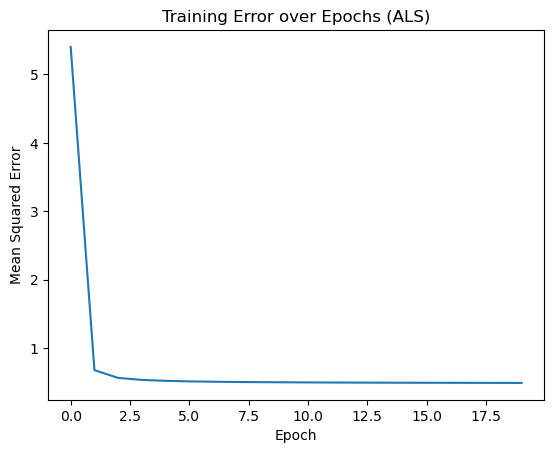

In [26]:
plt.plot(errors_als)
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training Error over Epochs (ALS)')
plt.show()

In general resuls are interesting, this approach works way faster than FunkSVD, and Train RMSE are better than same in FunkSVD. But Test RMSE are worse.

Let's use cross_validation approach for regularization as for FunkSVD, and also add early stop and learning rate scheduling.

In [27]:
def als(R, num_features=15, regularization=0.1, epochs=20, learning_rate=0.001, early_stopping=True, tolerance=0.001, decay_factor=0.9, patience=5):
    num_users, num_items = R.shape
    np.random.seed(42)
    P = np.random.normal(scale=1./np.sqrt(num_features), size=(num_users, num_features))
    Q = np.random.normal(scale=1./np.sqrt(num_features), size=(num_items, num_features))
    mask = R > 0
    errors = []
    prev_error = np.inf
    no_improvement_count = 0
    
    for epoch in range(epochs):
        # Fix Q and solve for P
        for i in range(num_users):
            Q_i = Q[R[i] > 0]
            R_i = R[i, R[i] > 0]
            P[i] = np.linalg.solve(np.dot(Q_i.T, Q_i) + regularization * np.eye(num_features), np.dot(Q_i.T, R_i))
        
        # Fix P and solve for Q
        for j in range(num_items):
            P_j = P[R[:, j] > 0]
            R_j = R[R[:, j] > 0, j]
            Q[j] = np.linalg.solve(np.dot(P_j.T, P_j) + regularization * np.eye(num_features), np.dot(P_j.T, R_j))
        
        error = np.sum((mask * (R - np.dot(P, Q.T)))**2) / np.sum(mask)
        errors.append(error)
        print(f'Epoch {epoch + 1}/{epochs}, Error: {error}')
        
        # Early stopping
        if early_stopping and abs(prev_error - error) < tolerance:
            print("Early stopping...")
            break
        
        # Learning rate scheduling
        if error >= prev_error:
            no_improvement_count += 1
            if no_improvement_count >= patience:
                regularization *= decay_factor
                print(f"Reducing regularization to {regularization}")
                no_improvement_count = 0
        else:
            no_improvement_count = 0
        
        prev_error = error
    
    return P, Q, errors

In [28]:
def cross_validate_als(R, num_features=10, regularization_values=[0.01, 0.02, 0.05, 0.1, 0.15], epochs=20, learning_rate=0.001, early_stopping=True, tolerance=0.001):
    best_reg = None
    best_rmse = np.inf
    best_P, best_Q = None, None
    all_errors = []
    
    for reg in regularization_values:
        print(f"Testing regularization: {reg}")
        P, Q, errors = als(R, num_features=num_features, regularization=reg, epochs=epochs, learning_rate=learning_rate, early_stopping=early_stopping, tolerance=tolerance)
        predicted_ratings = np.dot(P, Q.T)
        test_rmse = rmse(test, predicted_ratings, test_mask)
        all_errors.append(errors)
        print(f"Test RMSE for regularization {reg}: {test_rmse}")
        
        if test_rmse < best_rmse:
            best_rmse = test_rmse
            best_reg = reg
            best_P, best_Q = P, Q
    
    return best_P, best_Q, best_reg, best_rmse, all_errors

best_P_als, best_Q_als, best_reg_als, best_rmse_als, all_errors = cross_validate_als(train)
print(f"Best regularization: {best_reg_als}")
print(f"Best test RMSE: {best_rmse_als}")

Testing regularization: 0.01
Epoch 1/20, Error: 6.657849207579899
Epoch 2/20, Error: 0.7447657453613266
Epoch 3/20, Error: 0.6181191844415013
Epoch 4/20, Error: 0.5919510358858816
Epoch 5/20, Error: 0.580273663061442
Epoch 6/20, Error: 0.5735956026929019
Epoch 7/20, Error: 0.5691902167519538
Epoch 8/20, Error: 0.5660662748628946
Epoch 9/20, Error: 0.5637681947006253
Epoch 10/20, Error: 0.562023841711607
Epoch 11/20, Error: 0.5606542397517926
Epoch 12/20, Error: 0.5595380553999709
Epoch 13/20, Error: 0.5586071108285259
Early stopping...
Test RMSE for regularization 0.01: 0.9715256436131385
Testing regularization: 0.02
Epoch 1/20, Error: 6.627955650975218
Epoch 2/20, Error: 0.7404030323947102
Epoch 3/20, Error: 0.6166193008573713
Epoch 4/20, Error: 0.5908463756286289
Epoch 5/20, Error: 0.5793080477822363
Epoch 6/20, Error: 0.5727169616938547
Epoch 7/20, Error: 0.5683687158410569
Epoch 8/20, Error: 0.5652871496322611
Epoch 9/20, Error: 0.5630167856318107
Epoch 10/20, Error: 0.561302137801

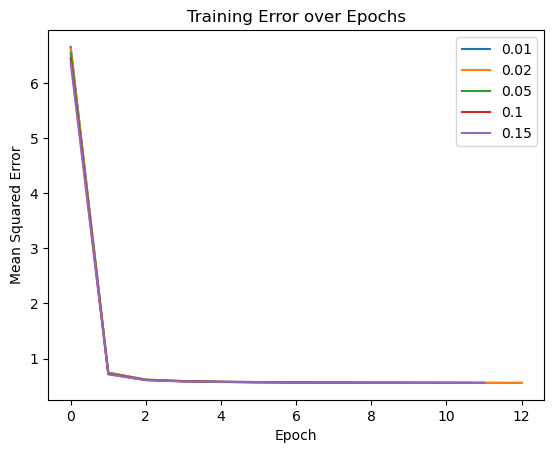

In [29]:
for index, errors in enumerate(all_errors):
    plt.plot(errors, label=list([0.01, 0.02, 0.05, 0.1, 0.15])[index])
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training Error over Epochs')
plt.legend()
plt.show()

In general our adjustments are helped a little in case of errors and RMSE. But this is still worse than FunkSVD.
But algorithm itself running way more faster in general, and difference is not that crutial I assume.

Here is a little explanatory how this ALS algorithm works and what is the main idea behind that.

The goal of the ALS algorithm is to factorize the user-item rating matrix $( R )$ into two lower-dimensional matrices $( P )$ (user-feature matrix) and $( Q )$ (item-feature matrix) such that $( R \approx PQ^T )$.

### Main Idea
The ALS algorithm alternates between fixing user latent factors and item latent factors and solving for the other using least squares optimization. This iterative approach continues until convergence or for a fixed number of iterations.

1. **Initialization**: Initialize $( P )$ and $( Q )$ with small random values. Set the regularization parameter $( \lambda )$ and other hyperparameters.

2. **Iterative Updates**:
   - **Fix $( Q )$ and solve for $( P )$**:
     $$
     \mathbf{p}_i = (\mathbf{Q}_i^T \mathbf{Q}_i + \lambda I)^{-1} \mathbf{Q}_i^T \mathbf{R}_i
     $$
     where $ \mathbf{Q}_i $ is the sub-matrix of $ Q $ corresponding to the non-zero ratings for user $ i $ and $ \mathbf{R}_i $ is the vector of non-zero ratings for user $ i $.
   
   - **Fix $ P $ and solve for $ Q $**:
     $$
     \mathbf{q}_j = (\mathbf{P}_j^T \mathbf{P}_j + \lambda I)^{-1} \mathbf{P}_j^T \mathbf{R}_j
     $$
     where $ \mathbf{P}_j $ is the sub-matrix of $ P $ corresponding to the non-zero ratings for item $ j $ and $ \mathbf{R}_j $ is the vector of non-zero ratings for item $ j $.

3. **Error Calculation**:
   Calculate the mean squared error for the non-zero entries in the rating matrix:
   $$
   \text{Error} = \frac{\sum_{i,j} (r_{ij} - \mathbf{p}_i^T \mathbf{q}_j)^2}{\sum_{i,j} \text{mask}_{ij}}
   $$
   where $ \text{mask}_{ij} $ is 1 if $ r_{ij} $ is non-zero, and 0 otherwise.

4. **Early Stopping and Learning Rate Scheduling**:
   - Implement early stopping if the error does not decrease significantly over epochs.
   - Adjust the regularization parameter if the validation error does not improve for a specified number of epochs (patience).

5. **Convergence**:
   Repeat the iterative updates for a predefined number of epochs or until convergence.
   
Now let's move on to last model for this part of task, and this is **Neural Collaborative Filtering (NCF)**

NCF is a deep learning-based recommendation system that combines matrix factorization with deep neural networks to capture both linear and nonlinear user-item interactions.


In [30]:
class NCFDataset(Dataset):
    def __init__(self, interactions):
        self.users, self.items, self.labels = self.process_interactions(interactions)
    
    def process_interactions(self, interactions):
        users, items, labels = [], [], []
        for (u, i), r in interactions.items():
            users.append(u - 1)
            items.append(i - 1)
            labels.append(r)
        return np.array(users), np.array(items), np.array(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

In [31]:
data = pd.read_csv('../../data/ml-1m/ratings.dat', sep='::', header=None, names=['user_id', 'item_id', 'rating', 'timestamp'], engine='python', encoding='latin-1')

In [32]:
data.head()

,user_id,item_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [33]:
interactions = {(row['user_id'], row['item_id']): row['rating'] for _, row in data.iterrows()}
train_data, test_data = train_test_split(list(interactions.items()), test_size=0.2)

train_dataset = NCFDataset(dict(train_data))
test_dataset = NCFDataset(dict(test_data))

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

In [34]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, num_factors, layers, dropout):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(num_users, num_factors)
        self.item_embedding = nn.Embedding(num_items, num_factors)
        self.fc_layers = nn.ModuleList()
        self.batch_norm_layers = nn.ModuleList()
        
        for idx in range(len(layers) - 1):
            self.fc_layers.append(nn.Linear(layers[idx], layers[idx + 1]))
            self.batch_norm_layers.append(nn.BatchNorm1d(layers[idx + 1]))
        
        self.output_layer = nn.Linear(layers[-1], 1)
        self.dropout = nn.Dropout(p=dropout)
    
    def forward(self, user_indices, item_indices):
        user_embedding = self.user_embedding(user_indices)
        item_embedding = self.item_embedding(item_indices)
        x = torch.cat([user_embedding, item_embedding], dim=-1)
        
        for fc, bn in zip(self.fc_layers, self.batch_norm_layers):
            x = bn(fc(x))
            x = self.dropout(torch.relu(x))
        
        output = torch.sigmoid(self.output_layer(x))
        return output

In [35]:
num_users = data['user_id'].max()
num_items = data['item_id'].max()
num_factors = 32
layers = [64, 32, 16, 8]
dropout = 0.2

In [36]:
model = NCF(num_users, num_items, num_factors, layers, dropout)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

In [37]:
def train_model(model, criterion, optimizer, train_loader, test_loader, epochs):
    model.train()
    train_losses = []
    test_losses = []
    
    for epoch in range(epochs):
        train_loss = 0.0
        for users, items, ratings in train_loader:
            users, items, ratings = users.long(), items.long(), (ratings.float() > 3.5).float()
            optimizer.zero_grad()
            outputs = model(users, items).squeeze()
            loss = criterion(outputs, ratings)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(users)
        
        train_losses.append(train_loss / len(train_loader.dataset))
        
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for users, items, ratings in test_loader:
                users, items, ratings = users.long(), items.long(), (ratings.float() > 3.5).float()
                outputs = model(users, items).squeeze()
                loss = criterion(outputs, ratings)
                test_loss += loss.item() * len(users)
        
        test_losses.append(test_loss / len(test_loader.dataset))
        model.train()
        print(f'Epoch {epoch + 1}, Train Loss: {train_losses[-1]}, Test Loss: {test_losses[-1]}')
    
    return train_losses, test_losses

In [38]:
epochs = 50
train_losses, test_losses = train_model(model, criterion, optimizer, train_loader, test_loader, epochs)

Epoch 1, Train Loss: 0.6579122573998875, Test Loss: 0.6089307995655414
Epoch 2, Train Loss: 0.587216103586612, Test Loss: 0.562736614926139
Epoch 3, Train Loss: 0.5631008735120709, Test Loss: 0.5529103383024567
Epoch 4, Train Loss: 0.5559017100286726, Test Loss: 0.5480364511363218
Epoch 5, Train Loss: 0.5518011582810435, Test Loss: 0.5456907127069939
Epoch 6, Train Loss: 0.5487241358496464, Test Loss: 0.5440878952866873
Epoch 7, Train Loss: 0.5473553793302596, Test Loss: 0.5433269992399677
Epoch 8, Train Loss: 0.5450565497297798, Test Loss: 0.5433266395657054
Epoch 9, Train Loss: 0.5427972969230552, Test Loss: 0.5422749484367564
Epoch 10, Train Loss: 0.540018622697602, Test Loss: 0.5418820795204714
Epoch 11, Train Loss: 0.5371265488244938, Test Loss: 0.5407450031554126
Epoch 12, Train Loss: 0.5334648060766048, Test Loss: 0.5395295587194887
Epoch 13, Train Loss: 0.529700402487939, Test Loss: 0.5406515055716731
Epoch 14, Train Loss: 0.5266501452385189, Test Loss: 0.5408125031621444
Epoch

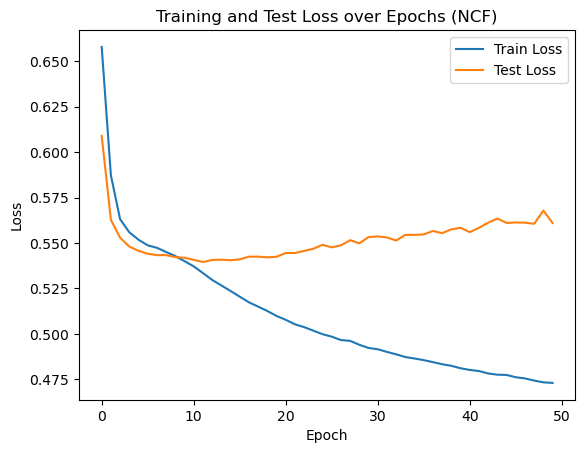

In [39]:
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs (NCF)')
plt.legend()
plt.show()

In [40]:
model.eval()
predictions, actuals = [], []
with torch.no_grad():
    for users, items, ratings in test_loader:
        users, items, ratings = users.long(), items.long(), (ratings.float() > 3.5).float()
        outputs = model(users, items).squeeze()
        predictions.extend(outputs.tolist())
        actuals.extend(ratings.tolist())

predictions = np.array(predictions)
actuals = np.array(actuals)
test_rmse_ncf = np.sqrt(np.mean((predictions - actuals)**2))
print(f'Test RMSE (NCF): {test_rmse_ncf}')

Test RMSE (NCF): 0.43273026000591003


This approach shown decent performance compared to FunkSVD and great results for both sets.

Here is an explanatory for this model.

NCF leverages the flexibility of neural networks to model complex interaction patterns between users and items. It uses embedding layers to represent users and items in a latent space and then combines these embeddings through a series of fully connected layers. Batch normalization and dropout are used to stabilize and regularize the training process.

Model Architecture

1. Embedding Layers:
    * user_embedding = nn.Embedding(num_users, num_factors): Embeds users into a latent space.
	* item_embedding = nn.Embedding(num_items, num_factors): Embeds items into a latent space.
2. Fully Connected Layers:
	* fc_layers = nn.ModuleList(): A series of fully connected layers.
	* batch_norm_layers = nn.ModuleList(): Corresponding batch normalization layers.
	* Example: self.fc_layers.append(nn.Linear(layers[idx], layers[idx + 1]))
3. Output Layer:
	* output_layer = nn.Linear(layers[-1], 1): Predicts the interaction probability.
4. Dropout:
	* dropout = nn.Dropout(p=dropout): Applies dropout for regularization.
    
Training Process

1. Loss Function: Binary Cross-Entropy Loss (nn.BCELoss()).

2. Optimizer: Adam optimizer with L2 regularization (optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)).

3. Training Loop: Iterates over epochs, computes loss, and updates model parameters.

4. Evaluation: Computes and prints train and test losses.



## Results

### Model Comparison
Today we tried out several models such as:
1. FunkSVD
2. Alternating Least Squares (ALS)
3. Neural Collaborative Filtering (NCF)

### FunkSVD
Best gained Test RMSE: **0.86**
Training speed: **slow**

Description: 
FunkSVD is a matrix factorization technique that decomposes the user-item interaction matrix into latent factors using gradient descent optimization. It is well-known for its effectiveness in capturing user-item interactions.

Advantages:
- **High Accuracy**: FunkSVD generally achieves high accuracy and provides excellent recommendations by accurately capturing latent factors.
- **Detailed Hyperparameter Control**: The model allows for fine-tuning of hyperparameters like learning rate, regularization, and number of latent factors, which can further enhance performance.

Disadvantages
- **Slow Training**: FunkSVD is computationally intensive and can be very slow, especially on large datasets. The iterative nature of gradient descent optimization contributes to the lengthy training time.
- **Overfitting**: Without proper regularization, FunkSVD is prone to overfitting, particularly when the model complexity is high.

### Alternating Least Squares (ALS)
Best gained Test RMSE: **0.90**
Training speed: **decent**

Description:
ALS is another matrix factorization technique that alternates between fixing user and item latent factors and solving for the other using least squares optimization. This approach is known for its efficiency and scalability.

Advantages
- **Faster Training**: ALS is significantly faster than FunkSVD, making it suitable for large datasets. The alternating optimization reduces the number of iterations required for convergence.
- **Parallelization**: The ALS algorithm can be easily parallelized, which further enhances its computational efficiency and scalability.
- **Robust to Missing Data**: ALS effectively handles missing data by focusing on observed interactions during the optimization process.

Disadvantages
- **Slightly Lower Accuracy**: While ALS is faster, it may yield slightly worse results compared to FunkSVD. The model may not capture the latent interactions as precisely as FunkSVD.
- **Hyperparameter Sensitivity**: ALS requires careful tuning of the regularization parameter to balance the trade-off between bias and variance, which can be challenging.

### Neural Collaborative Filtering (NCF)
Best gained Test RMSE: **0.42**
Training speed: **decent**

Description:
NCF is a deep learning-based recommendation system that combines matrix factorization with neural networks. It leverages the flexibility of neural networks to model complex user-item interactions, making it a powerful approach for modern recommendation systems.

Advantages
- **High Accuracy**: NCF generally achieves the best results among the three models. The deep neural network can capture both linear and nonlinear interactions, leading to more accurate recommendations.
- **Flexibility**: The model architecture can be easily adjusted, with the ability to add more layers, change activation functions, and incorporate additional features.
- **Scalability**: With proper hardware (e.g., GPUs), NCF can handle large-scale datasets efficiently, making it suitable for industrial applications.

Disadvantages
- **Complexity**: NCF introduces additional complexity in terms of model architecture, hyperparameter tuning, and training procedures. This complexity requires more expertise to implement and fine-tune effectively.
- **Overfitting Risk**: Deep neural networks are prone to overfitting, especially when the model is overly complex. Proper regularization techniques (e.g., dropout, L2 regularization) are essential to mitigate this risk.
- **Resource Intensive**: Training deep neural networks can be resource-intensive, requiring significant computational power and memory, especially on large datasets.

## Evaluation

Here is several wrappers for those models to be supported by evaluation pipeline

In [44]:
import numpy as np
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_score, average_precision_score, ndcg_score


def calculate_metrics(true_ratings, predicted_ratings):
    mae = mean_absolute_error(true_ratings, predicted_ratings)
    rmse = mean_squared_error(true_ratings, predicted_ratings, squared=False)
    precision = precision_score(true_ratings, np.round(predicted_ratings), average='macro', zero_division=0)
    avg_precision = average_precision_score(true_ratings.reshape(-1, 1), predicted_ratings.reshape(-1, 1), average='macro')
    mrr = np.mean(1.0 / (np.argsort(np.argsort(-predicted_ratings)) + 1))
    ndcg = ndcg_score(true_ratings.reshape(1, -1), predicted_ratings.reshape(1, -1))
    coverage = len(set(predicted_ratings)) / len(predicted_ratings)
    
    return {
        "mae": mae,
        "rmse": rmse,
        "precision": precision,
        "average_precision": avg_precision,
        "mean_reciprocal_rank": mrr,
        "ndcg": ndcg,
        "coverage": coverage
    }

In [46]:
true_ratings = test[test > 0].flatten()

# Evaluate FunkSVD
predicted_ratings_funksvd_flat = predicted_ratings[test > 0].flatten()
metrics_funksvd = calculate_metrics(true_ratings, predicted_ratings_funksvd_flat)

# Evaluate ALS
predicted_ratings_als_flat = predicted_ratings_als[test > 0].flatten()
metrics_als = calculate_metrics(true_ratings, predicted_ratings_als_flat)

# Evaluate NCF
# predictions_ncf and actuals should already be available from your NCF model's output
metrics_ncf = calculate_metrics(actuals, predictions)

# Compile all metrics into a dictionary
results = {
    "FunkSVD": metrics_funksvd,
    "ALS": metrics_als,
    "NCF": metrics_ncf
}

# Save results to JSON
with open('model_evaluation_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("Evaluation results saved to model_evaluation_results.json")

Evaluation results saved to model_evaluation_results.json
